In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned unscaled data (better for EDA — real values)
df = pd.read_csv('C:/Users/surya/Desktop/customer-marketing-ml/data/cleaned_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (2236, 33)


,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Age,TotalSpend,TotalPurchases,TotalChildren,TotalCampaignsAccepted,EnrollmentYear,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,2,58138.0,0,0,58,635,88,546,172,88,...,69,1617,25,0,0,2012,False,True,False,False
1,2,46344.0,1,1,38,11,1,6,2,1,...,72,27,6,2,0,2014,False,True,False,False
2,2,71613.0,0,0,26,426,49,127,111,21,...,61,776,21,0,0,2013,False,False,True,False
3,2,26646.0,1,0,26,11,4,20,10,3,...,42,53,8,1,0,2014,False,False,True,False
4,4,58293.0,1,0,94,173,43,118,46,27,...,45,422,19,1,0,2014,True,False,False,False


### Campaign Response Rate

Response Distribution:
  Did NOT accept (0): 1902 customers (85.1%)
  Accepted (1):       334 customers (14.9%)


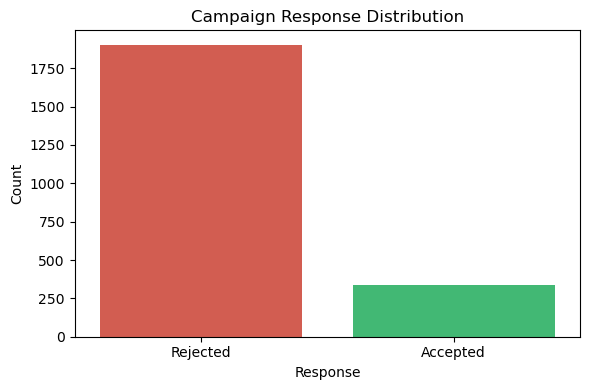

In [4]:
# How balanced is our target variable?
response_counts = df['Response'].value_counts()
response_pct = df['Response'].value_counts(normalize=True) * 100

print("Response Distribution:")
print(f"  Did NOT accept (0): {response_counts[0]} customers ({response_pct[0]:.1f}%)")
print(f"  Accepted (1):       {response_counts[1]} customers ({response_pct[1]:.1f}%)")

plt.figure(figsize=(6,4))
sns.countplot(x='Response', data=df, palette=['#E74C3C', '#2ECC71'])
plt.title('Campaign Response Distribution')
plt.xticks([0,1], ['Rejected', 'Accepted'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Income Distribution

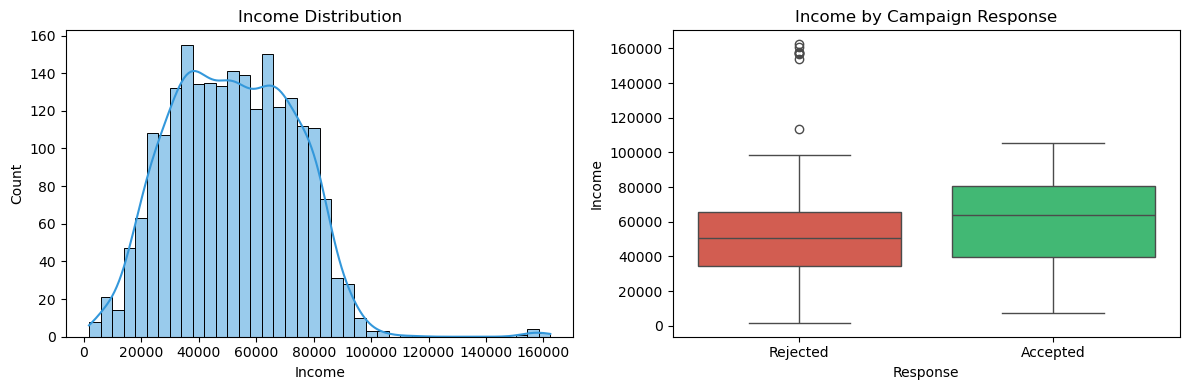

In [5]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Income'], bins=40, kde=True, color='#3498DB')
plt.title('Income Distribution')
plt.xlabel('Income')

plt.subplot(1, 2, 2)
sns.boxplot(x='Response', y='Income', data=df, palette=['#E74C3C', '#2ECC71'])
plt.title('Income by Campaign Response')
plt.xticks([0,1], ['Rejected', 'Accepted'])

plt.tight_layout()
plt.show()

### Age Distribution

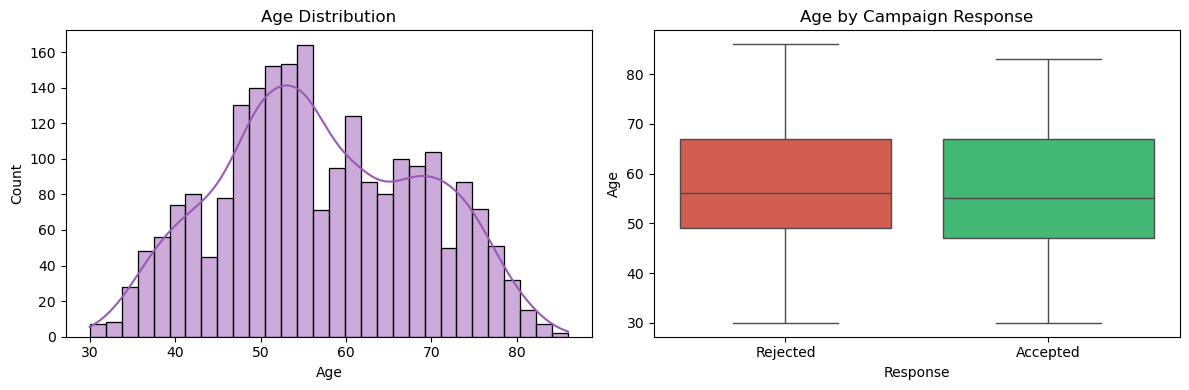

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=30, kde=True, color='#9B59B6')
plt.title('Age Distribution')
plt.xlabel('Age')

plt.subplot(1, 2, 2)
sns.boxplot(x='Response', y='Age', data=df, palette=['#E74C3C', '#2ECC71'])
plt.title('Age by Campaign Response')
plt.xticks([0,1], ['Rejected', 'Accepted'])

plt.tight_layout()
plt.show()

### Spending Pattern 

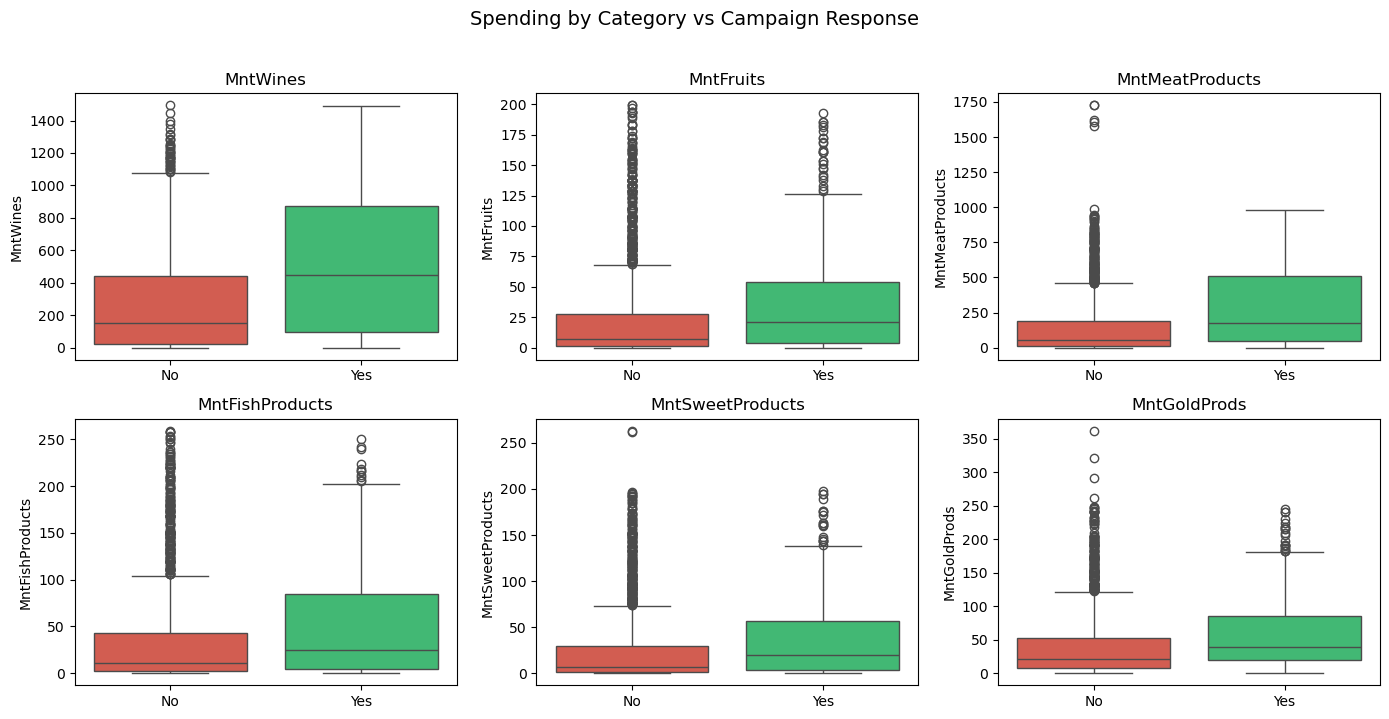

In [11]:
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

plt.figure(figsize=(14, 7))
for i, col in enumerate(spend_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='Response', y=col, data=df, palette=['#E74C3C', '#2ECC71'])
    plt.title(col)
    plt.xticks([0,1], ['No', 'Yes'])
    plt.xlabel('')

plt.suptitle('Spending by Category vs Campaign Response', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Purchase Channels

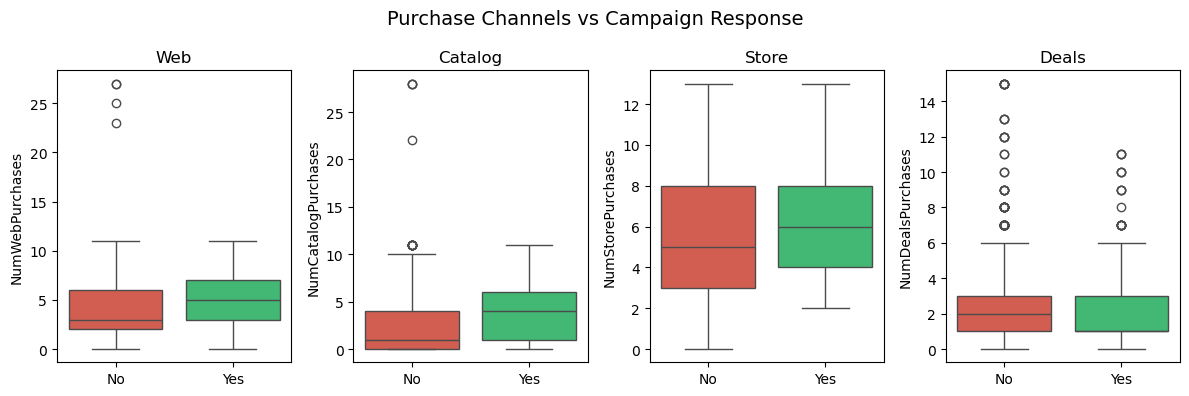

In [8]:
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 
                 'NumStorePurchases', 'NumDealsPurchases']

plt.figure(figsize=(12, 4))
for i, col in enumerate(purchase_cols):
    plt.subplot(1, 4, i+1)
    sns.boxplot(x='Response', y=col, data=df, palette=['#E74C3C', '#2ECC71'])
    plt.title(col.replace('Num','').replace('Purchases',''))
    plt.xticks([0,1], ['No', 'Yes'])
    plt.xlabel('')

plt.suptitle('Purchase Channels vs Campaign Response', fontsize=14)
plt.tight_layout()
plt.show()

### Correlation Heatmap

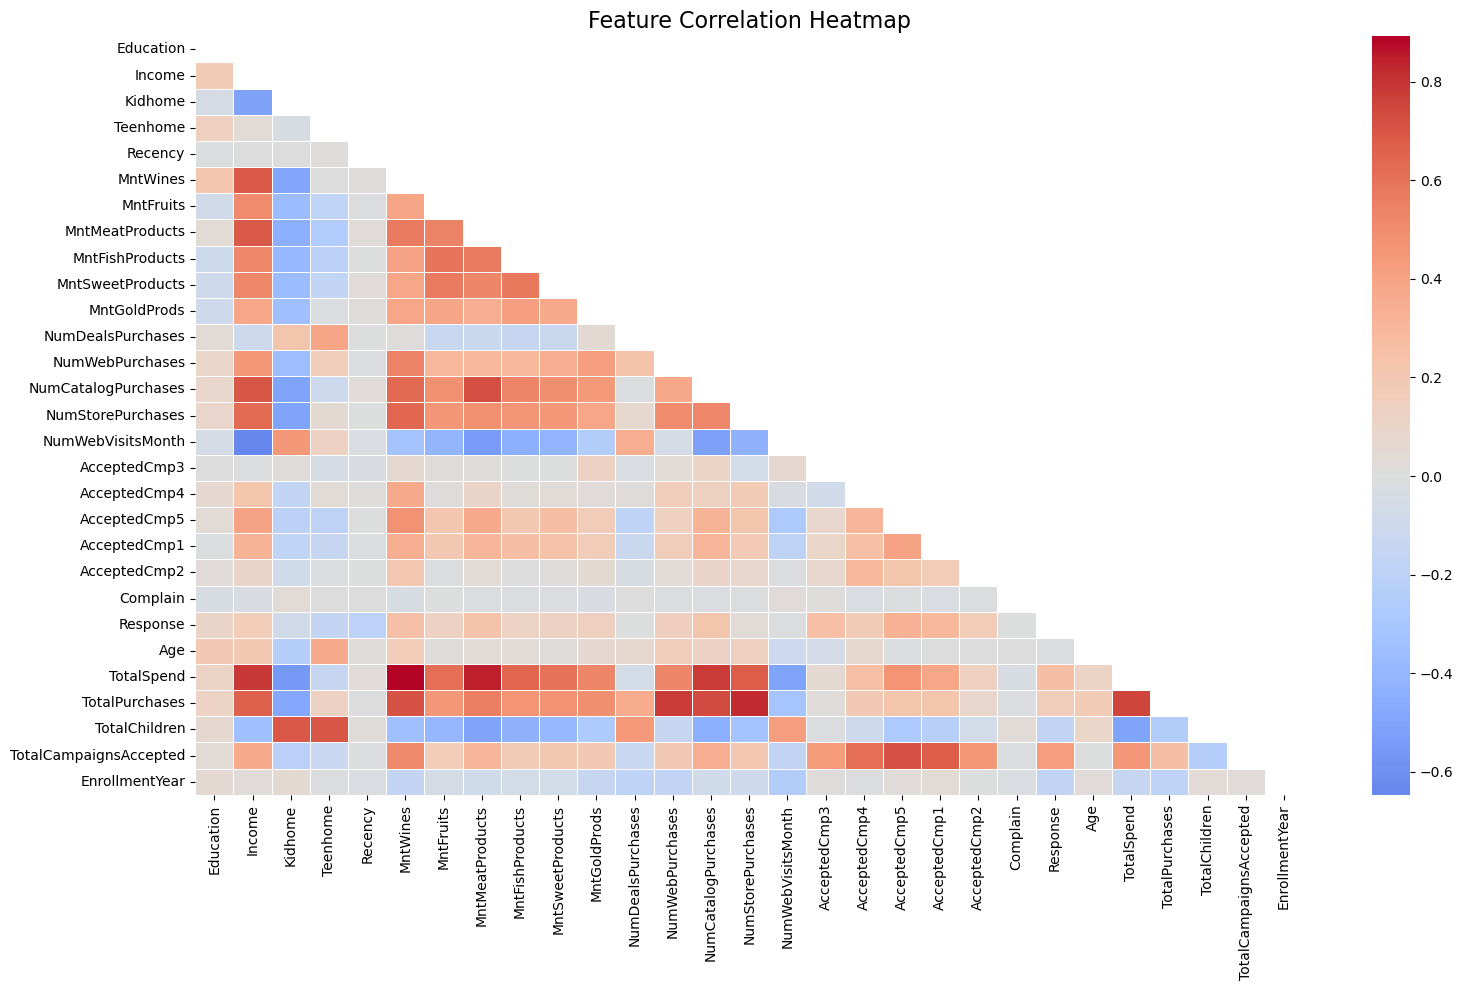


Top features correlated with Response:
TotalCampaignsAccepted    0.426206
AcceptedCmp5              0.328148
AcceptedCmp1              0.293849
TotalSpend                0.265615
AcceptedCmp3              0.254106
MntWines                  0.247280
MntMeatProducts           0.236548
NumCatalogPurchases       0.220813
AcceptedCmp4              0.176847
AcceptedCmp2              0.169234
Name: Response, dtype: float64


In [12]:
plt.figure(figsize=(16, 10))

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', 
            center=0, linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# Print top correlations with Response
print("\nTop features correlated with Response:")
print(corr['Response'].sort_values(ascending=False)[1:11])

### Key Insights Summary

In [15]:
print("=" * 50)
print("KEY EDA INSIGHTS")
print("=" * 50)

print(f"\n1. DATASET BALANCE:")
print(f"   Accepted campaign:     {len(df[df['Response']==1])} customers (14.9%)")
print(f"   Rejected campaign:     {len(df[df['Response']==0])} customers (85.1%)")
print(f"   ⚠ Imbalanced dataset — needs handling in ML section")

print(f"\n2. INCOME INSIGHT:")
print(f"   Accepted avg income:   ${df[df['Response']==1]['Income'].mean():,.0f}")
print(f"   Rejected avg income:   ${df[df['Response']==0]['Income'].mean():,.0f}")
print(f"   ✅ Higher income customers more likely to accept")

print(f"\n3. SPENDING INSIGHT:")
print(f"   Accepted avg spend:    ${df[df['Response']==1]['TotalSpend'].mean():,.0f}")
print(f"   Rejected avg spend:    ${df[df['Response']==0]['TotalSpend'].mean():,.0f}")
print(f"   ✅ Accepted customers spend nearly 2x more")

print(f"\n4. AGE INSIGHT:")
print(f"   Accepted avg age:      {df[df['Response']==1]['Age'].mean():.0f} years")
print(f"   Rejected avg age:      {df[df['Response']==0]['Age'].mean():.0f} years")
print(f"   ➡ Age has no significant impact on acceptance")

print(f"\n5. PURCHASE CHANNELS:")
print(f"   Accepted avg catalog:  {df[df['Response']==1]['NumCatalogPurchases'].mean():.1f} purchases")
print(f"   Rejected avg catalog:  {df[df['Response']==0]['NumCatalogPurchases'].mean():.1f} purchases")
print(f"   Accepted avg web:      {df[df['Response']==1]['NumWebPurchases'].mean():.1f} purchases")
print(f"   Rejected avg web:      {df[df['Response']==0]['NumWebPurchases'].mean():.1f} purchases")
print(f"   ✅ Accepted customers buy more via catalog & web")

print(f"\n6. SPENDING CATEGORIES:")
print(f"   Accepted avg wines:    ${df[df['Response']==1]['MntWines'].mean():,.0f}")
print(f"   Rejected avg wines:    ${df[df['Response']==0]['MntWines'].mean():,.0f}")
print(f"   Accepted avg meat:     ${df[df['Response']==1]['MntMeatProducts'].mean():,.0f}")
print(f"   Rejected avg meat:     ${df[df['Response']==0]['MntMeatProducts'].mean():,.0f}")
print(f"   ✅ Accepted customers spend more on wines & meat")

print(f"\n7. TOP FEATURES CORRELATED WITH RESPONSE:")
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
top_corr = corr['Response'].sort_values(ascending=False)[1:6]
for feat, val in top_corr.items():
    print(f"   {feat:<30} {val:.3f}")

print(f"\n8. CAMPAIGN HISTORY:")
print(f"   Accepted avg prev campaigns:  {df[df['Response']==1]['TotalCampaignsAccepted'].mean():.1f}")
print(f"   Rejected avg prev campaigns:  {df[df['Response']==0]['TotalCampaignsAccepted'].mean():.1f}")
print(f"   ✅ Customers who accepted before are likely to accept again")



KEY EDA INSIGHTS

1. DATASET BALANCE:
   Accepted campaign:     334 customers (14.9%)
   Rejected campaign:     1902 customers (85.1%)
   ⚠ Imbalanced dataset — needs handling in ML section

2. INCOME INSIGHT:
   Accepted avg income:   $60,183
   Rejected avg income:   $50,507
   ✅ Higher income customers more likely to accept

3. SPENDING INSIGHT:
   Accepted avg spend:    $987
   Rejected avg spend:    $539
   ✅ Accepted customers spend nearly 2x more

4. AGE INSIGHT:
   Accepted avg age:      57 years
   Rejected avg age:      57 years
   ➡ Age has no significant impact on acceptance

5. PURCHASE CHANNELS:
   Accepted avg catalog:  4.2 purchases
   Rejected avg catalog:  2.4 purchases
   Accepted avg web:      5.1 purchases
   Rejected avg web:      3.9 purchases
   ✅ Accepted customers buy more via catalog & web

6. SPENDING CATEGORIES:
   Accepted avg wines:    $503
   Rejected avg wines:    $269
   Accepted avg meat:     $294
   Rejected avg meat:     $145
   ✅ Accepted customers

### What the data is telling us:
💰 Money matters most

Accepted customers earn $10k more on average
Accepted customers spend 2x more ($987 vs $539)
They spend more on wines & meat specifically — premium products

🛒 How they shop

Accepted customers buy more via catalog (4.2 vs 2.4) and web (5.1 vs 3.9)
These are higher-engagement channels

📢 Campaign history is the strongest signal

Customers who accepted before have 1.0 avg previous acceptances
Rejectors only have 0.2
Meaning → past behavior predicts future behavior strongly

🎂 Age doesn't matter

Both groups average 57 years — age is not a deciding factor

### Ideal Customer

✅ Higher income
✅ Spends more (especially on wines & meat)
✅ Shops via catalog or web
✅ Has accepted a campaign before